In [1]:
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (455, 30)
X_test shape: (114, 30)


In [2]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(
    score_func=f_classif,
    k=10
)

X_train_selected = selector.fit_transform(
    X_train,
    y_train
)

X_test_selected = selector.transform(X_test)

print("Original training shape:", X_train.shape)
print("Selected training shape:", X_train_selected.shape)

print("\nSelected features:")
print(X_train.columns[selector.get_support()])

Original training shape: (455, 30)
Selected training shape: (455, 10)

Selected features:
Index(['mean radius', 'mean perimeter', 'mean area', 'mean concavity',
       'mean concave points', 'worst radius', 'worst perimeter', 'worst area',
       'worst concavity', 'worst concave points'],
      dtype='str')


In [3]:
feature_scores = pd.DataFrame({
    "Feature": X_train.columns,
    "F-Score": selector.scores_
})

feature_scores = feature_scores.sort_values(
    by="F-Score",
    ascending=False
)

print(feature_scores.head(15))

                 Feature     F-Score
27  worst concave points  795.223341
22       worst perimeter  719.598823
7    mean concave points  703.364031
20          worst radius  687.430367
2         mean perimeter  565.485755
23            worst area  541.713694
0            mean radius  523.613907
3              mean area  469.516453
6         mean concavity  416.374874
26       worst concavity  365.747389
5       mean compactness  269.466042
25     worst compactness  257.926057
13            area error  214.858763
10          radius error  212.499767
12       perimeter error  198.422440


In [4]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr_all_features = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=1000))
])

lr_all_features.fit(X_train, y_train)

pred_all = lr_all_features.predict(X_test)

accuracy_all = accuracy_score(y_test, pred_all)

print("Accuracy with all 30 features:", accuracy_all)

Accuracy with all 30 features: 0.9824561403508771


In [5]:
lr_selected_features = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=1000))
])

lr_selected_features.fit(
    X_train_selected,
    y_train
)

pred_selected = lr_selected_features.predict(
    X_test_selected
)

accuracy_selected = accuracy_score(
    y_test,
    pred_selected
)

print("Accuracy with 10 selected features:", accuracy_selected)

Accuracy with 10 selected features: 0.9473684210526315


In [6]:
from sklearn.feature_selection import SelectKBest, f_classif

results = []

for k in [5, 10, 15, 20, 25, 30]:

    selector = SelectKBest(
        score_func=f_classif,
        k=k
    )

    X_train_k = selector.fit_transform(
        X_train,
        y_train
    )

    X_test_k = selector.transform(
        X_test
    )

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("lr", LogisticRegression(max_iter=1000))
    ])

    model.fit(X_train_k, y_train)

    predictions = model.predict(X_test_k)

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    results.append({
        "K": k,
        "Accuracy": accuracy
    })

results_df = pd.DataFrame(results)

print(results_df)

    K  Accuracy
0   5  0.938596
1  10  0.947368
2  15  0.964912
3  20  0.973684
4  25  0.973684
5  30  0.982456


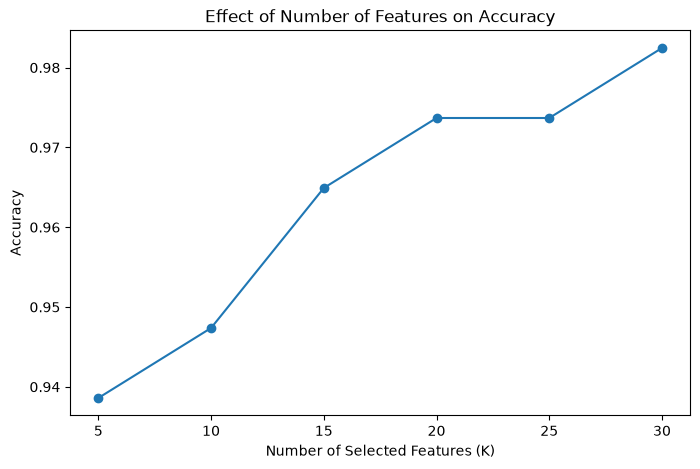

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    results_df["K"],
    results_df["Accuracy"],
    marker="o"
)

plt.xlabel("Number of Selected Features (K)")
plt.ylabel("Accuracy")
plt.title("Effect of Number of Features on Accuracy")

plt.xticks(results_df["K"])

plt.show()

In [9]:
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier

rf_selector_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model_selector = SelectFromModel(
    rf_selector_model
)

X_train_model_selected = model_selector.fit_transform(
    X_train,
    y_train
)

X_test_model_selected = model_selector.transform(
    X_test
)

selected_features_model = X_train.columns[
    model_selector.get_support()
]

print("Original number of features:", X_train.shape[1])
print("Selected number of features:", X_train_model_selected.shape[1])

print("\nSelected features:")
print(selected_features_model)

Original number of features: 30
Selected number of features: 11

Selected features:
Index(['mean radius', 'mean perimeter', 'mean area', 'mean concavity',
       'mean concave points', 'area error', 'worst radius', 'worst perimeter',
       'worst area', 'worst concavity', 'worst concave points'],
      dtype='str')


In [10]:
lr_model_selected = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=1000))
])

lr_model_selected.fit(
    X_train_model_selected,
    y_train
)

pred_model_selected = lr_model_selected.predict(
    X_test_model_selected
)

accuracy_model_selected = accuracy_score(
    y_test,
    pred_model_selected
)

print(
    "Accuracy with model-selected features:",
    accuracy_model_selected
)

Accuracy with model-selected features: 0.9473684210526315


In [11]:
feature_selection_results = pd.DataFrame({
    "Method": [
        "All Features",
        "SelectKBest (10)",
        "SelectFromModel (11)"
    ],
    "Number of Features": [
        30,
        10,
        11
    ],
    "Accuracy": [
        accuracy_all,
        accuracy_selected,
        accuracy_model_selected
    ]
})

print(feature_selection_results)

                 Method  Number of Features  Accuracy
0          All Features                  30  0.982456
1      SelectKBest (10)                  10  0.947368
2  SelectFromModel (11)                  11  0.947368


In [13]:
from sklearn.feature_selection import RFE

rfe_model = LogisticRegression(
    max_iter=1000
)

rfe_selector = RFE(
    estimator=rfe_model,
    n_features_to_select=10
)

# Scale the data first because Logistic Regression is scale-sensitive
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fit RFE on training data only
rfe_selector.fit(
    X_train_scaled,
    y_train
)

selected_features_rfe = X_train.columns[
    rfe_selector.get_support()
]

print("Selected features using RFE:")
print(selected_features_rfe)
X_train_rfe = rfe_selector.transform(X_train_scaled)
X_test_rfe = rfe_selector.transform(X_test_scaled)

lr_rfe = LogisticRegression(max_iter=1000)

lr_rfe.fit(
    X_train_rfe,
    y_train
)

pred_rfe = lr_rfe.predict(X_test_rfe)

accuracy_rfe = accuracy_score(
    y_test,
    pred_rfe
)

print("Accuracy with RFE-selected features:", accuracy_rfe)

Selected features using RFE:
Index(['mean area', 'radius error', 'area error', 'worst radius',
       'worst texture', 'worst perimeter', 'worst area', 'worst smoothness',
       'worst concavity', 'worst concave points'],
      dtype='str')
Accuracy with RFE-selected features: 0.9736842105263158


In [14]:
feature_selection_results.loc[len(feature_selection_results)] = [
    "RFE (10)",
    10,
    accuracy_rfe
]

print(feature_selection_results)

                 Method  Number of Features  Accuracy
0          All Features                  30  0.982456
1      SelectKBest (10)                  10  0.947368
2  SelectFromModel (11)                  11  0.947368
3              RFE (10)                  10  0.973684


In [15]:
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold

rfecv_model = LogisticRegression(
    max_iter=1000
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rfecv_selector = RFECV(
    estimator=rfecv_model,
    step=1,
    cv=cv,
    scoring="accuracy"
)

rfecv_selector.fit(
    X_train_scaled,
    y_train
)

print("Optimal number of features:", rfecv_selector.n_features_)

selected_features_rfecv = X_train.columns[
    rfecv_selector.support_
]

print("\nSelected features:")
print(selected_features_rfecv)

Optimal number of features: 25

Selected features:
Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean fractal dimension', 'radius error',
       'texture error', 'perimeter error', 'area error', 'compactness error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst concavity', 'worst concave points',
       'worst symmetry'],
      dtype='str')


In [16]:
X_train_rfecv = rfecv_selector.transform(X_train_scaled)
X_test_rfecv = rfecv_selector.transform(X_test_scaled)

lr_rfecv = LogisticRegression(max_iter=1000)

lr_rfecv.fit(X_train_rfecv, y_train)

pred_rfecv = lr_rfecv.predict(X_test_rfecv)

accuracy_rfecv = accuracy_score(y_test, pred_rfecv)

print("Accuracy with RFECV-selected features:", accuracy_rfecv)

Accuracy with RFECV-selected features: 0.9736842105263158


In [18]:
print(rfecv_selector.cv_results_.keys())
rfecv_results = pd.DataFrame({
    "Number of Features": rfecv_selector.cv_results_["n_features"],
    "Mean CV Score": rfecv_selector.cv_results_["mean_test_score"],
    "Std CV Score": rfecv_selector.cv_results_["std_test_score"]
})

print(rfecv_results)

dict_keys(['mean_test_score', 'std_test_score', 'split0_test_score', 'split1_test_score', 'split2_test_score', 'split3_test_score', 'split4_test_score', 'split0_ranking', 'split1_ranking', 'split2_ranking', 'split3_ranking', 'split4_ranking', 'split0_support', 'split1_support', 'split2_support', 'split3_support', 'split4_support', 'n_features'])
    Number of Features  Mean CV Score  Std CV Score
0                    1       0.920879      0.016150
1                    2       0.947253      0.016150
2                    3       0.949451      0.016447
3                    4       0.936264      0.020143
4                    5       0.964835      0.012815
5                    6       0.967033      0.018388
6                    7       0.967033      0.015541
7                    8       0.964835      0.018906
8                    9       0.967033      0.013900
9                   10       0.964835      0.010767
10                  11       0.958242      0.010767
11                  12      

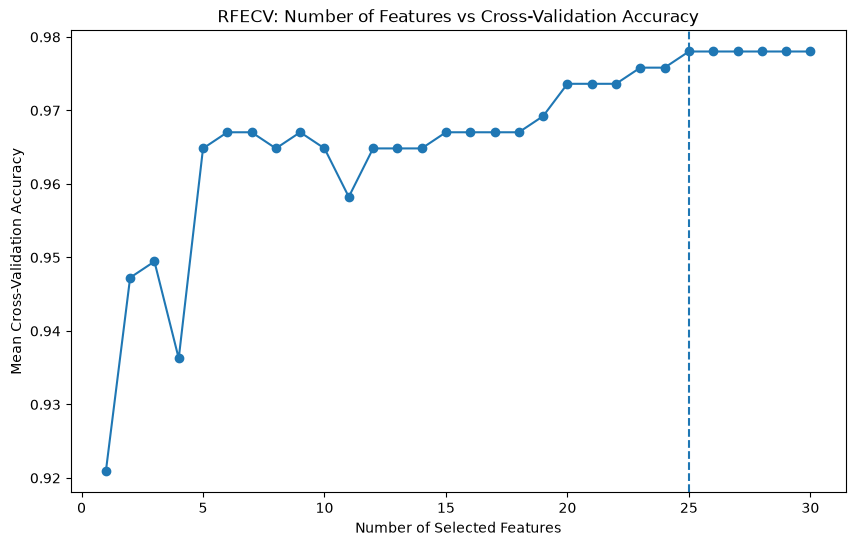

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    rfecv_results["Number of Features"],
    rfecv_results["Mean CV Score"],
    marker="o"
)

plt.xlabel("Number of Selected Features")
plt.ylabel("Mean Cross-Validation Accuracy")
plt.title("RFECV: Number of Features vs Cross-Validation Accuracy")

plt.axvline(
    rfecv_selector.n_features_,
    linestyle="--"
)

plt.show()